# Trigonometry Refresher for Calculus
### Introduction to Calculus (University of Sydney)

This notebook serves as an interactive refresher on **Sine, Cosine, and Tangent** interpreted through the lens of calculus. We will move away from static triangles and look at these functions as continuous, dynamic waveforms.

---

## 1. Setup & Libraries
We will use `numpy` for mathematical operations and `matplotlib` to visualize the geometric transformations and continuous waves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure clean, crisp vector graphics in the notebook
%config InlineBackend.figure_format = 'retina'

## 2. Radians vs. Degrees
In calculus, we use **radians** because they represent a natural relationship between an angle and the arc length of a circle ($s = r\theta$). If $r=1$, the arc length exactly equals the angle in radians.

Let's write a quick script to visualize standard calculus angles ($0, \frac{\pi}{6}, \frac{\pi}{4}, \frac{\pi}{3}, \frac{\pi}{2}, \pi, 2\pi$) and their degree equivalents.

In [2]:
# Define key radian points
radian_points = np.array([0, np.pi/6, np.pi/4, np.pi/3, np.pi/2, np.pi, 2*np.pi])
labels = ['0', 'π/6', 'π/4', 'π/3', 'π/2', 'π', '2π']

print(f"{'Radians':<10} | {'Degrees':<10}")
print("-" * 25)
for rad, label in zip(radian_points, labels):
    deg = np.degrees(rad)
    print(f"{label:<10} | {deg:<10.1f}°")

Radians    | Degrees   
-------------------------
0          | 0.0       °
π/6        | 30.0      °
π/4        | 45.0      °
π/3        | 60.0      °
π/2        | 90.0      °
π          | 180.0     °
2π         | 360.0     °


## 3. The Geometric Origins: Right-Angled Triangles ($SOH-CAH-TOA$)
Before scaling trigonometry to infinite periodic waves, its foundations rely on the ratios of side lengths within a static right-angled triangle relative to an acute angle $\theta$:

* **Sine ($\\sin\\theta$):** $\\frac{\\text{Opposite}}{\\text{Hypotenuse}}$ ($SOH$)
* **Cosine ($\\cos\\theta$):** $\\frac{\\text{Adjacent}}{\\text{Hypotenuse}}$ ($CAH$)
* **Tangent ($\\tan\\theta$):** $\\frac{\\text{Opposite}}{\\text{Adjacent}}$ ($TOA$)

Let's visualize a classic basic geometric right triangle ($3-4-5$ triangle structure) below to inspect these structural ratios.

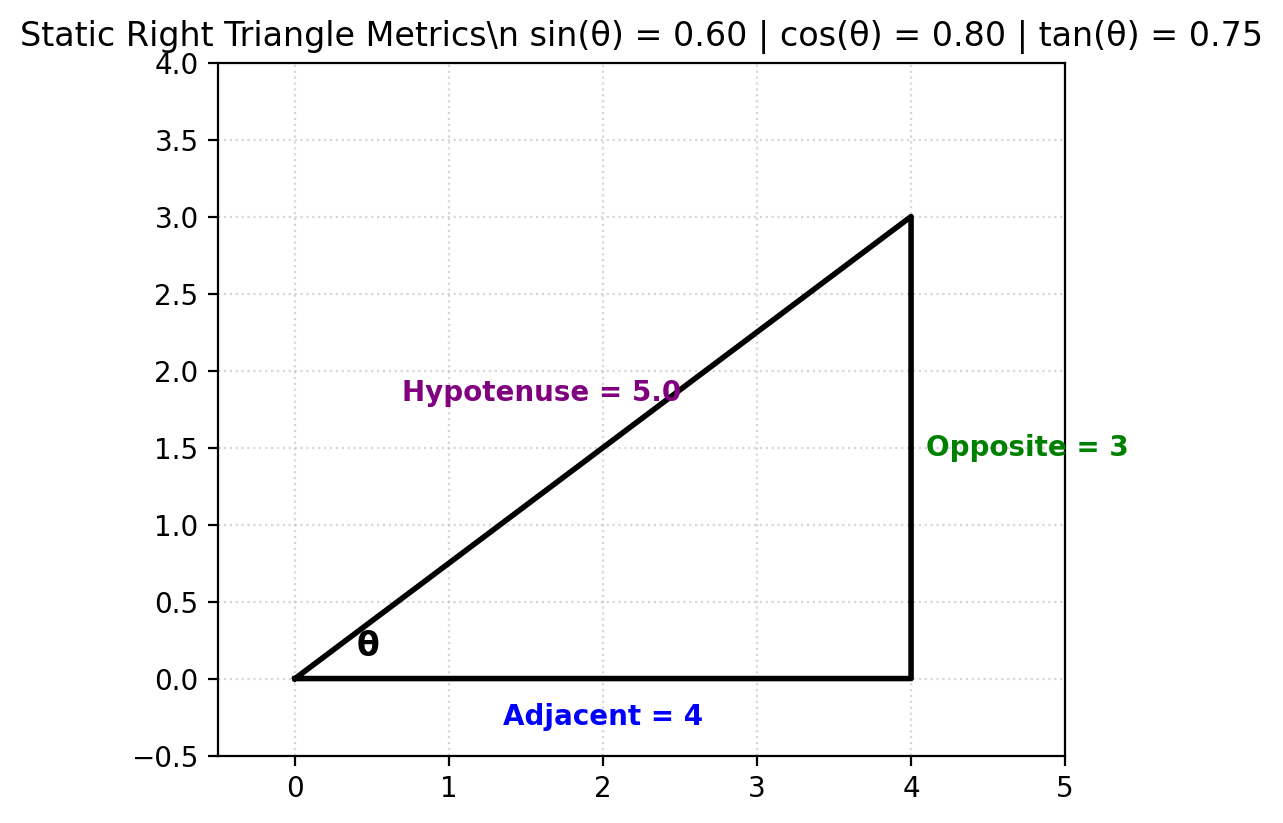

In [3]:
# Constructing vertices for a standard 3-4-5 right triangle
adjacent_side = 4
opposite_side = 3
hypotenuse = np.sqrt(adjacent_side**2 + opposite_side**2)

plt.figure(figsize=(6, 4.5))
plt.plot([0, adjacent_side, adjacent_side, 0], [0, 0, opposite_side, 0], color='black', linewidth=2)

# Text markup annotations
plt.text(adjacent_side / 2, -0.3, f'Adjacent = {adjacent_side}', ha='center', fontweight='bold', color='blue')
plt.text(adjacent_side + 0.1, opposite_side / 2, f'Opposite = {opposite_side}', va='center', fontweight='bold', color='green')
plt.text(adjacent_side / 2 - 0.4, opposite_side / 2 + 0.3, f'Hypotenuse = {hypotenuse}', ha='center', fontweight='bold', color='purple')
plt.text(0.4, 0.15, 'θ', fontsize=12, fontweight='bold')

# Standard structural values calculation
val_sin = opposite_side / hypotenuse
val_cos = adjacent_side / hypotenuse
val_tan = opposite_side / adjacent_side

plt.title(f'Static Right Triangle Metrics\\n sin(θ) = {val_sin:.2f} | cos(θ) = {val_cos:.2f} | tan(θ) = {val_tan:.2f}')
plt.xlim(-0.5, adjacent_side + 1)
plt.ylim(-0.5, opposite_side + 1)
plt.grid(True, linestyle=':', alpha=0.5)
plt.gca().set_aspect('equal', 'box')
plt.show()

## 4. The Unit Circle Viewpoint
Instead of $SOH-CAH-TOA$, calculus redefines trigonometric ratios as coordinates on a circle where $r = 1$. By setting Hypotenuse = 1:
* $\cos(\theta) = x / 1 = x$
* $\sin(\theta) = y / 1 = y$
* $\tan(\theta) = \frac{y}{x}$

Run the cell below to plot a dynamic angle on the Unit Circle.

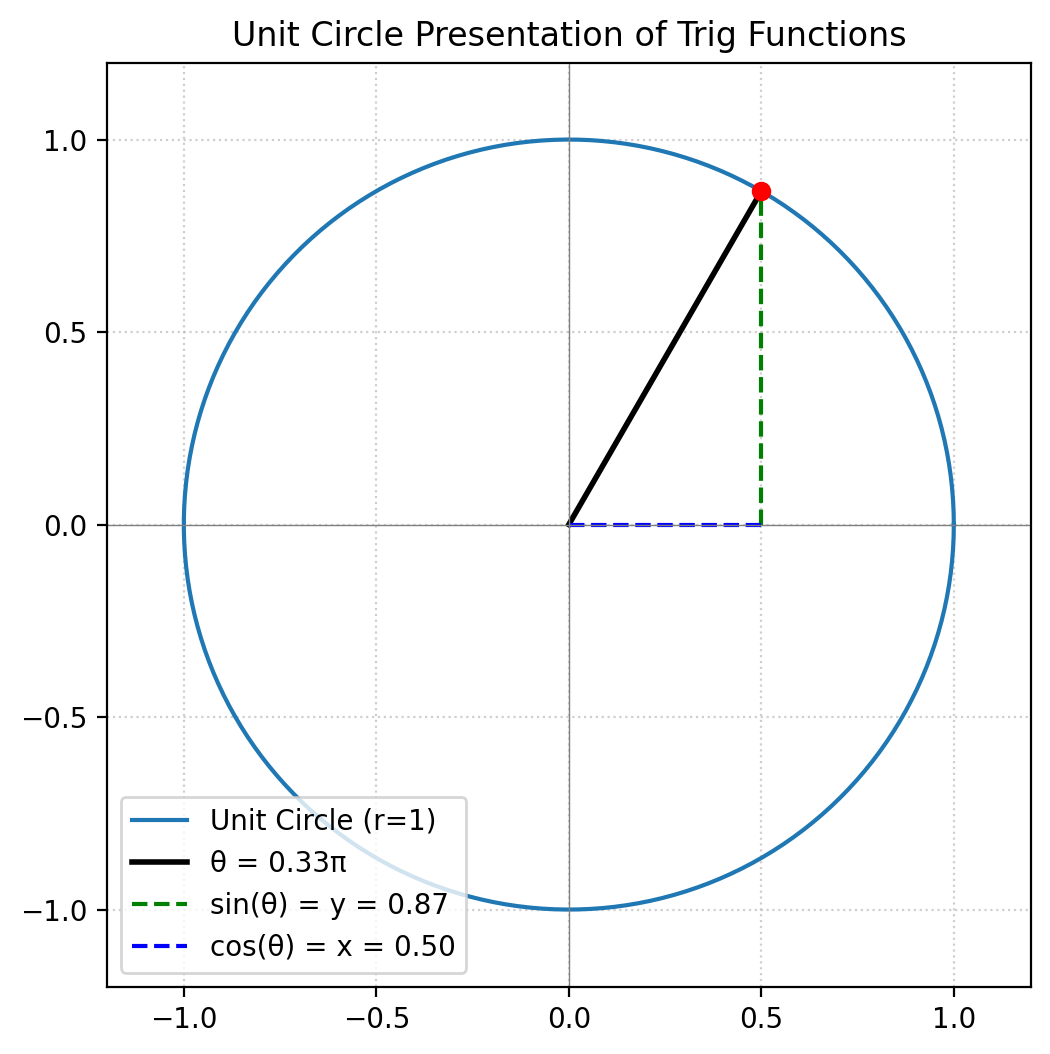

In [4]:
# Set an angle (e.g., pi/3 or 60 degrees)
theta = np.pi / 3
x_coord = np.cos(theta)
y_coord = np.sin(theta)

# Plotting the Unit Circle
angles = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(6,6))
plt.plot(np.cos(angles), np.sin(angles), label='Unit Circle (r=1)')

# Plot the terminal ray, x (cos), and y (sin) components
plt.plot([0, x_coord], [0, y_coord], color='black', linewidth=2, label=f'θ = {theta/np.pi:.2f}π')
plt.scatter([x_coord], [y_coord], color='red', zorder=5)
plt.vlines(x_coord, 0, y_coord, colors='green', linestyles='dashed', label=f'sin(θ) = y = {y_coord:.2f}')
plt.hlines(0, 0, x_coord, colors='blue', linestyles='dashed', label=f'cos(θ) = x = {x_coord:.2f}')

# Formatting
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.gca().set_aspect('equal', 'box')
plt.title('Unit Circle Presentation of Trig Functions')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 5. Continuous Waves: Mapping to the Cartesian Plane
As $\theta$ moves continuously along the real number line, tracking the $x$ and $y$ output values constructs periodic functions. 

Notice how $\tan(x)$ goes to infinity wherever $\cos(x) = 0$ (e.g., $\pm\frac{\pi}{2}$).

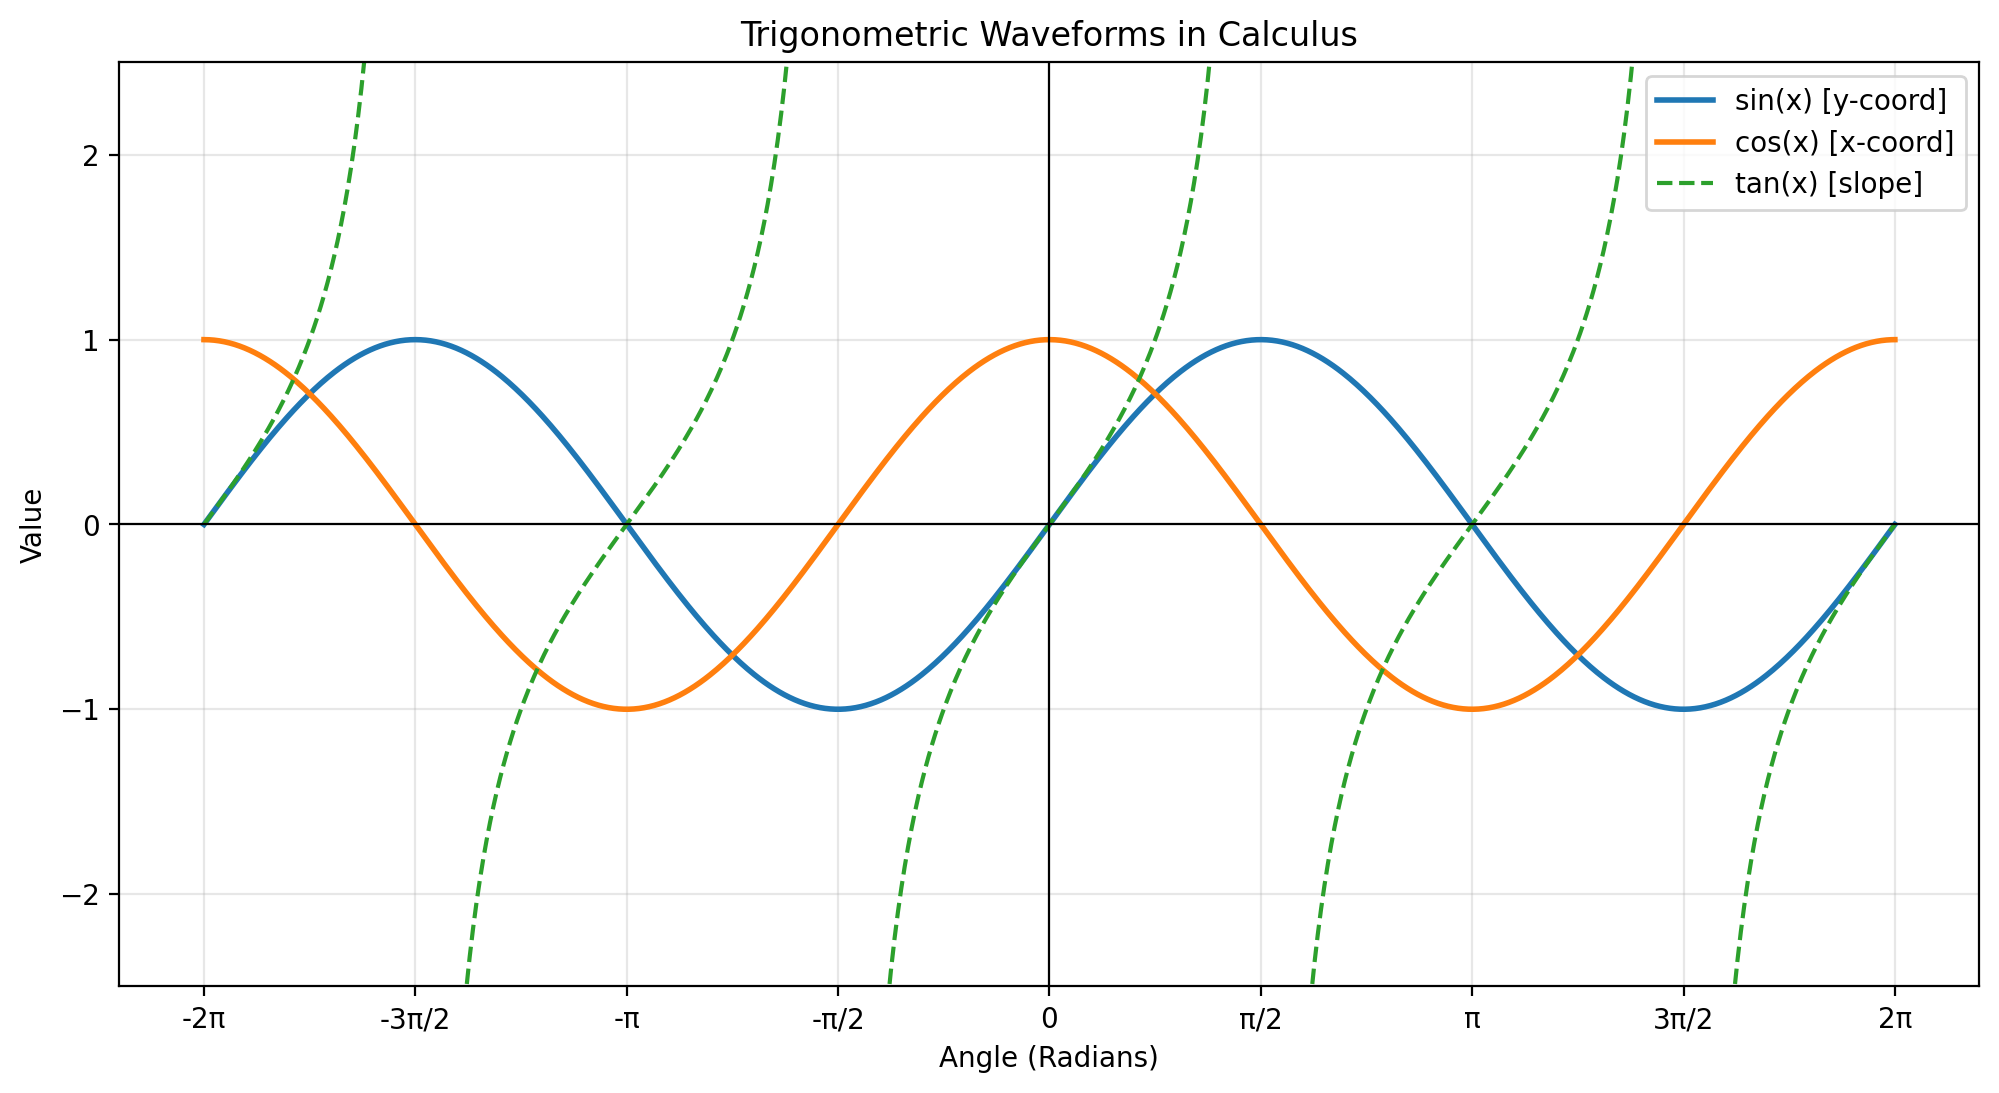

In [5]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y_sin = np.sin(x)
y_cos = np.cos(x)
y_tan = np.tan(x)

# Mask out large jumps in tangent for clean plotting near asymptotes
y_tan[abs(y_tan) > 5] = np.nan

plt.figure(figsize=(12, 6))

# Plot Sine & Cosine
plt.plot(x, y_sin, label='sin(x) [y-coord]', linewidth=2)
plt.plot(x, y_cos, label='cos(x) [x-coord]', linewidth=2)
plt.plot(x, y_tan, label='tan(x) [slope]', linewidth=1.5, linestyle='--')

# Clean up x-axis ticks to show radians cleanly
plt.xticks([-2*np.pi, -1.5*np.pi, -np.pi, -0.5*np.pi, 0, 0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi],
           ['-2π', '-3π/2', '-π', '-π/2', '0', 'π/2', 'π', '3π/2', '2π'])

plt.title('Trigonometric Waveforms in Calculus')
plt.xlabel('Angle (Radians)')
plt.ylabel('Value')
plt.ylim(-2.5, 2.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Numerical Verification of Identities
Calculus depends heavily on structural substitutions. Let's numerically verify the fundamental Pythagorean Identity:
$$\sin^2(x) + \cos^2(x) = 1$$
for a broad sample set.

In [6]:
sample_angles = np.random.uniform(-10, 10, 5)

print(f"{'Angle (rad)':<12} | {'sin^2(x)':<12} | {'cos^2(x)':<12} | {'sin^2(x) + cos^2(x)':<20}")
print("-" * 65)
for angle in sample_angles:
    sin_sq = np.sin(angle)**2
    cos_sq = np.cos(angle)**2
    total = sin_sq + cos_sq
    print(f"{angle:<12.4f} | {sin_sq:<12.4f} | {cos_sq:<12.4f} | {total:<20.4f}")

Angle (rad)  | sin^2(x)     | cos^2(x)     | sin^2(x) + cos^2(x) 
-----------------------------------------------------------------
-6.9436      | 0.3763       | 0.6237       | 1.0000              
-2.0359      | 0.7988       | 0.2012       | 1.0000              
2.8225       | 0.0984       | 0.9016       | 1.0000              
0.8360       | 0.5505       | 0.4495       | 1.0000              
2.9888       | 0.0232       | 0.9768       | 1.0000              
